# Text Classification and Quantitative Evaluation
#### By Jeremy Merrill for Lede 2026


This notebook classifies tweets using the OpenAI interface. Right now, it's set up to classify Elon Musk's Twitter posts into four categories: election, broader politics, his companies and other.

It includes a cost estimation and code for quantitative evaluation (seeing how you did, then adjusting to try to do better).

It can serve as a template for any kind of classification, and you should feel free to copy and reuse it.

In [17]:
import os
import pandas as pd
from IPython.display import display, Markdown
from tqdm.auto import tqdm # makes pretty progress bars
tqdm.pandas()              # makes pretty progress bars in pandas with progress_apply()

# this should be familiar!
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENROUTER_API_KEY_LEDE"][:8] + "..."

'sk-or-v1...'

In [29]:
## setting up API key


## importing data
data_dir = ""
data_full_raw = pd.read_csv('aggregated_comments.csv')


SIZE_OF_SAMPLE_FOR_HANDCODING = 100
##
## take a random sample to test our prompts against
text_column_name = "commentBody" # change this to match your own dataset
data_full_raw.dropna(subset=[text_column_name], inplace=True)

# exclude user replies
data_full = data_full_raw[data_full_raw['commentType'] == 'comment']

# if you already did the handcoding, make sure the sample you're using is the right set.
WE_ALREADY_HANDCODED = os.path.exists("handcoded.csv")
if WE_ALREADY_HANDCODED:
  handcoded = pd.read_csv("handcoded.csv")
  data_sample = data_full[data_full.index.isin(handcoded.index)]
else:
  data_sample = data_full.sample(n=SIZE_OF_SAMPLE_FOR_HANDCODING, random_state=613)

data_sample = data_sample.copy() # avoid annoying warnings!

In [30]:
data_sample.head()

,index,author,url,recipeRating,commentBody,commentType,userID,commentRecommendations
32397,17,Vaughn Vreeland,https://cooking.nytimes.com/recipes/1027336-pe...,4(114),"This was perfect. I used raspberry jam, but I ...",comment,150171772,0
30872,6,Vaughn Vreeland,https://cooking.nytimes.com/recipes/776535584-...,5(316),Hate to reheat scones in microwave. Better in ...,comment,105033914,1
93520,13,Alexa Weibel,https://cooking.nytimes.com/recipes/1026111-ch...,5(349),Has anyone made this as a sheet cake?,comment,67561178,2
40138,20,J. Kenji López-Alt,https://cooking.nytimes.com/recipes/1023012-sa...,"4(10,943)",Just made this and it was so delicious.\nI add...,comment,130201244,1
64993,12,Melissa Clark,https://cooking.nytimes.com/recipes/1027726-ch...,5(534),Made half-batch waiting for Lunar Eclipse at 6...,comment,65443072,5


In [31]:

## setting up our connection to an API client for an AI provider
# for Lede, we're using OpenRouter, which connects to most providers
# but I've provided code for connect to other providers directly, if you want to do that in real life

USE_OPENROUTER=True

from anthropic import Anthropic

if USE_OPENROUTER:
  from openrouter import OpenRouter
else:
  from openai import OpenAI
  from mistralai.client import Mistral

if USE_OPENROUTER:
  openrouter_client = OpenRouter(api_key=os.environ.get("OPENROUTER_API_KEY_LEDE"))
else:
  openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY_LEDE"))
  mistral_client = Mistral(api_key=os.environ.get("MISTRAL_API_KEY_LEDE"))
anthropic_client = Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY_LEDE"),) # intentionally created outside of the if; we'll use anthropic_client to count tokens (even if we're using openrouter)


A basic format for a prompt is below. Using the web version of ChatGPT (chatgpt.com) tweak this until you're pretty consistently getting reasonable results.

In [32]:
## prompt
## start with the one YOU tried in the LLM web interface
## don't worry, we'll adjust it later.
## Jeremy's is at the very bottom, if you need to reference it, but please come
##   up with your own.


# Be sure to list the categories (defined below!) with the magic phrase {categories}
prompt_base = """

Here's a comment from NYT Cooking:{comment_text}

Choose the single most specific category that applies from this list:

positive_user_made_as_written
positive_user_describing_changes
thinks_recipe_is_flawed_due_to_flavor
thinks_recipe_is_flawed_due_to_technique_or_equipment
thinks_recipe_is_flawed_due_to_cooking_time
thinks_recipe_is_inauthentic
thinks_ingredients_hard_to_find
user_responding_to_other_user
question
maybe_not_about_the_recipe

Prioritize structural recipe suggestions over general experience.
"""

from enum import Enum, IntEnum

# force the AI to ONLY guess fromn the options we ask you.
# you can change these names! (and perhaps should!)
# - the AI sees the _value_, not the key (it sees "broader_political_issues_except_us_election", not "other_politics")
# - the key is just for you -- a shorthand
# - some AIs have trouble with complicated names, so it's better to stick to lowercase, no special characters
#     (as of early June 2026 -- maybe this will be fixed)
class CommentOptions(str, Enum):
    positive_user_made_as_written = "positive_user_made_as_written"
    positive_user_describing_changes = "positive_user_describing_changes"
    thinks_recipe_is_flawed_due_to_flavor = "thinks_recipe_is_flawed_due_to_flavor"
    thinks_recipe_is_flawed_due_to_technique_or_equipment = "thinks_recipe_is_flawed_due_to_technique_or_equipment"
    thinks_recipe_is_flawed_due_to_cooking_time = "thinks_recipe_is_flawed_due_to_cooking_time"
    thinks_recipe_is_inauthentic = "thinks_recipe_is_inauthentic"
    thinks_ingredients_hard_to_find = "thinks_ingredients_hard_to_find"
    user_responding_to_other_user = "user_responding_to_other_user"
    question = "question"
    maybe_not_about_the_recipe = "maybe_not_about_the_recipe"

# for convenience, make a column in our dataframes with the prompt for each item
data_sample_prompt_column = data_sample.apply(lambda row: prompt_base.format(
    comment_text=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in CommentOptions])
), axis="columns")
full_data_prompt_column = data_full.apply(lambda row: prompt_base.format(
    comment_text=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in CommentOptions])
), axis="columns")
data_sample_prompt_column.iloc[0]

"\n\nHere's a comment from NYT Cooking:This was perfect. I used raspberry jam, but I can't think of a jam that wouldn't work here. The icing on top is great hint of sweetness.\n\nIt was so good, I had to give out slices to make sure I didn't eat the whole thing.\n\nChoose the single most specific category that applies from this list:\n\npositive_user_made_as_written\npositive_user_describing_changes\nthinks_recipe_is_flawed_due_to_flavor\nthinks_recipe_is_flawed_due_to_technique_or_equipment\nthinks_recipe_is_flawed_due_to_cooking_time\nthinks_recipe_is_inauthentic\nthinks_ingredients_hard_to_find\nuser_responding_to_other_user\nquestion\nmaybe_not_about_the_recipe\n\nPrioritize structural recipe suggestions over general experience.\n"

In [33]:
## cost estimation

from strip_tags import strip_tags
import tiktoken
def count_tokens(model, text):
  if "claude" in model and os.environ.get("ANTHROPIC_API_KEY_LEDE"):
    return anthropic_client.messages.count_tokens(model=model, messages=[{"content": text, "role": "user"}])
  elif "gpt" in model:
    encoding = tiktoken.encoding_for_model('gpt-4o') # most modern models use the same tokenizer
    tokens = encoding.encode(text)
    return len(tokens)
  else:
    return count_tokens("gpt-4o", text) # for estimation purposes, pretend mistral is chatgpt...

INPUT_TOKEN_COSTS = {
    "gpt-5-mini": 0.40 / 1_000_000,  # https://openai.com/api/pricing/
    "gpt-5.4-mini": 0.75 / 1_000_000,
    "gpt-5.4": 2.5 / 1_000_000,
    "gpt-5.5": 5 / 1_000_000,
    "gpt-5.4-nano": 0.2 / 1_000_000,
    "mistral-medium-latest": 1.5 / 1_000_000, # https://mistral.ai/pricing#api-pricing
    "mistral-large-latest":  0.5 / 1_000_000,  # No, I don't know why medium is more expensive than large.
    "claude-haiku-4-5": 1 / 1_000_000,
    "claude-sonnet-4-6": 3 / 1_000_000
}
# ignores outputs, since the model will output fairly little text

def estimate_cost(model, token_count):
    return token_count * INPUT_TOKEN_COSTS[model]

In [34]:

# IMPORTANT: let's pick a model to use
# it's got to be listed in INPUT_TOKEN_COSTS up above

DEFAULT_MODEL_TO_USE = 'gpt-5.4'
display(Markdown("Pick a model to use: \n" + "\n - ".join(list(INPUT_TOKEN_COSTS.keys()))))
MODEL_TO_USE = 'gpt-5.4'

while MODEL_TO_USE not in INPUT_TOKEN_COSTS.keys():
  MODEL_TO_USE = input(f"type a model name (press enter for default: {DEFAULT_MODEL_TO_USE}): ").strip()
  if MODEL_TO_USE == "":
    MODEL_TO_USE = DEFAULT_MODEL_TO_USE


Pick a model to use: 
gpt-5-mini
 - gpt-5.4-mini
 - gpt-5.4
 - gpt-5.5
 - gpt-5.4-nano
 - mistral-medium-latest
 - mistral-large-latest
 - claude-haiku-4-5
 - claude-sonnet-4-6

The code blocks below will let you estimate costs. If it's too pricey with `gpt-5.4`, consider a cheaper model.

In [35]:
## cost estimation sample

count_tokens_for_our_model = lambda text: count_tokens(MODEL_TO_USE, text)

token_count_sample = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(data_sample_prompt_column))
"Sample would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_sample))

'Sample would cost: $0.04'

In [36]:
## cost estimation for full dataset
token_count_full = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(full_data_prompt_column))
"Full dataset would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_full))

'Full dataset would cost: $37.59'

Below is the actual call to the OpenAI API (or your chosen LLM). Run your sample on the same model you want to use for your real data.

**BUT FIRST**: adjust the categories below to match what you defined in your prompt.

In [37]:

## a lot of boilerplate for sending our prompt + tweet to the model and getting an answer
from pydantic import BaseModel


class CookingCommentValidOptions(BaseModel):
  classification: CommentOptions

SYSTEM_PROMPT = "You are a helpful assistant"

def anthropic_classify(prompt_including_tweet):
    # put our prompt into the blob that OpenAI expects
    message = anthropic_client.messages.parse(
        max_tokens=1024,
        # system=SYSTEM_PROMPT, # causes trouble with structured outputs, oddly
        messages = [
            {
                "role": "user",
                "content": prompt_including_tweet,
            }
        ],
        model=MODEL_TO_USE,
        output_format=CookingCommentValidOptions
    )
    return message.content[0].parsed_output.classification.value if message.content[0].parsed_output else None

def mistral_classify(prompt_including_tweet):
    # put our prompt into the blob that OpenAI expects
    chat_response = mistral_client.chat.parse(
      model=MODEL_TO_USE,
      messages=[
          {
              "role": "system",
              "content": SYSTEM_PROMPT
          },
          {
              "role": "user",
              "content": prompt_including_tweet
          },
      ],
      response_format=CookingCommentValidOptions,
      max_tokens=256,
      temperature=0
    )
    return chat_response.choices[0].message.parsed.classification.value if chat_response.choices[0].message.parsed else None

def chatgpt_classify(prompt_including_tweet):
    # put our prompt into the blob that OpenAI expects
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": prompt_including_tweet,
        }
    ]
    chat_completion = openai_client.responses.parse(
        input=messages,
        model=MODEL_TO_USE,
        text_format=CookingCommentValidOptions,
    )

    # get the answer out of the blob that OpenAI returns.
    resp = chat_completion.output_parsed.classification.value if chat_completion.output_parsed else None
    return resp

openrouter_model_names = {
    "gpt-5-mini": "openai/gpt-5-mini",
    "gpt-5.4-mini": "openai/gpt-5.4-mini",
    "gpt-5.4": "openai/gpt-5.4",
    "gpt-5.5": "openai/gpt-5.5",
    "gpt-5.4-nano": "openai/gpt-5.4-nano",
    "mistral-medium-latest": "mistralai/mistral-medium-3-5",
    "mistral-large-latest": "mistralai/mistral-large-2512",
    "claude-4.5-haiku": "anthropic/claude-4.5-haiku",
    "claude-4.6-sonnet": "anthropic/claude-4.6-sonnet"
}
def openrouter_classify(prompt_including_tweet):
    response = openrouter_client.chat.send(
        model=openrouter_model_names[MODEL_TO_USE],
        messages=[
            {"role": "user", "content": prompt_including_tweet}
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "musk_tweet_classification",
                "strict": True,
                "schema": CookingCommentValidOptions.model_json_schema(),
            },
        },
    )
    return  CookingCommentValidOptions.model_validate_json(
        response.choices[0].message.content
    ).classification.value

def classify(prompt_including_tweet):
  "A wrapper for the provider-specific classification functions"
  if USE_OPENROUTER:
    return openrouter_classify(prompt_including_tweet)
  else:
    if "mistral" in MODEL_TO_USE == "mistral-medium-latest":
      return mistral_classify(prompt_including_tweet)
    elif "claude" in MODEL_TO_USE:
      return anthropic_classify(prompt_including_tweet)
    elif "gpt" in MODEL_TO_USE:
      return chatgpt_classify(prompt_including_tweet)
    else:
      raise ValueError("Unknown model")

In [38]:
# ask ChatGPT about each and every tweet IN THE SAMPLE, using the prompt we made above
data_sample["ai_guess"] = data_sample_prompt_column.progress_apply(classify)

100%|██████████| 100/100 [02:07<00:00,  1.27s/it]


In [39]:
display(Markdown("## Here are a few results. How good did we do?"))
with pd.option_context("display.max_colwidth", 500):
  display(
      data_sample[[text_column_name, "ai_guess"]].head(50)
  )

## Here are a few results. How good did we do?

,commentBody,ai_guess
32397,"This was perfect. I used raspberry jam, but I can't think of a jam that wouldn't work here. The icing on top is great hint of sweetness.\n\nIt was so good, I had to give out slices to make sure I didn't eat the whole thing.",positive_user_describing_changes
30872,Hate to reheat scones in microwave. Better in toaster oven or regular oven to maintain crunchy exterior! Diced apricot and crystallized ginger are the best add ins.,thinks_recipe_is_flawed_due_to_technique_or_equipment
93520,Has anyone made this as a sheet cake?,question
40138,Just made this and it was so delicious.\nI added mushrooms 🍄 to the recipe to make it a bit more substantial. So yummy and thank you for the amazing recipe!,positive_user_describing_changes
64993,"Made half-batch waiting for Lunar Eclipse at 6 am here in Maine. Sadly, the moon dropped below the tree line. But the cookies were delicious! Plenty of orange flavor with Trader Joe's Seville Orange marmalade. I did add a handful of unsalted, roasted pistachios, in chopped, which added crunch.",positive_user_describing_changes
59698,Made this the other night and it was much easier to make than I thought it would be. Heat was perfect and didn't overpower the flavor. There were no leftovers. This will go into the regular menu rotation.,positive_user_made_as_written
35745,"Make the crust with Ginger Snaps (Nabisco, really) rather than graham cracker. The flavor rush is wonderful. You will never go back.",positive_user_describing_changes
2599,"Little dry, would simmer less next time. \nOnly had butter beans, worked great. \nCould double the red pepper to get more of a kick. \nUsed half and half, worked great\nMozzetta sun dried tomatoes \nGood fresh tomatoes might be a nice addition",positive_user_describing_changes
48100,Can I use vegetable stock?,question
69832,This recipe one me over; I''m now a fan of salmon! The maple sweet with the tangy flavors- so good. I only had baby spinach which didn't work out too well; next time will use chard which should be heartier. Thank you.,positive_user_describing_changes


# STOP FOR MONDAY

Don't read below here.

- beep
- boop
- beep
- boop
- beep
- boop
- beep
- boop
- seriously don't read past here until Tuesday
- beep
- boop
- beep
- boop
- beep
- boop
- beep
- boop
- stop it!!!!!!!!!
- beep
- boop
- beep
- boop


# time to do some hand-coding

**Vibes are not enough**

All we did yesterday was look at a handful of examples and tried to guess from that if our prompt was good enough. But hopefully you realized that five or ten wasn't enough! Now we're going to be a little bit more certain -- while keeping in mind that, in real life, in the news business, we can't spend days doing this.

Before we classify all of the data (which costs a few dollars), we're going to try to see how well our prompt and workflow are doing, and if we can improve it.

First, we're going to manually check the sample results by categorizing each row of the data ourselves (individually).

Next, we will tweak the prompt several times, discuss common ways to improve our prompts, and see if those tweaks really do improve the accuracy.

Then, we will discuss fancy ways of measuring different kinds of accuracy.

Then we'll tweak again, and see if those work.

In [40]:
# This code will adds a new blank 'groundtruth' column, then exports it to CSV, and downloads it.

data_sample.to_csv(data_dir + 'aggregated_comments_for_hand_classification.csv')

Now open that CSV in Google Sheets or Excel, and fill in the `groundtruth` column with the right answer.

Then upload it back here (by clicking the folder icon to the left), or, if you're using a Jupyter Notebook, put it in the same folder as your notebook. **Important** name the file `handcoded.csv`.

In [42]:
handcoded = pd.read_csv("handcoded.csv").set_index("url") # for some countries add `, delimiter=";"`
if "groundtruth" not in handcoded.columns:
  print("uh oh, your handcoded.csv doesn't have a column named groundtruth")
  assert "groundtruth" in handcoded.columns
if handcoded.groundtruth.isna().any() or (handcoded.groundtruth == '').any():
  print("uh oh, there are some blanks in your handcoded.csv's groundtruth column. go fix that!")

# if the ai_guess column got lost in the process... we'll grab it again
if "ai_guess" not in handcoded:
  handcoded = handcoded.merge(data_sample[["ai_guess"]], right_index=True, left_index=True)

In [43]:
from sklearn.metrics import accuracy_score
display(Markdown("Accuracy score: {:.1%}. Is that good?".format(
    accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
)))


Accuracy score: 96.0%. Is that good?

# Stop here!
## Different ways of measuring accuracy


  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  

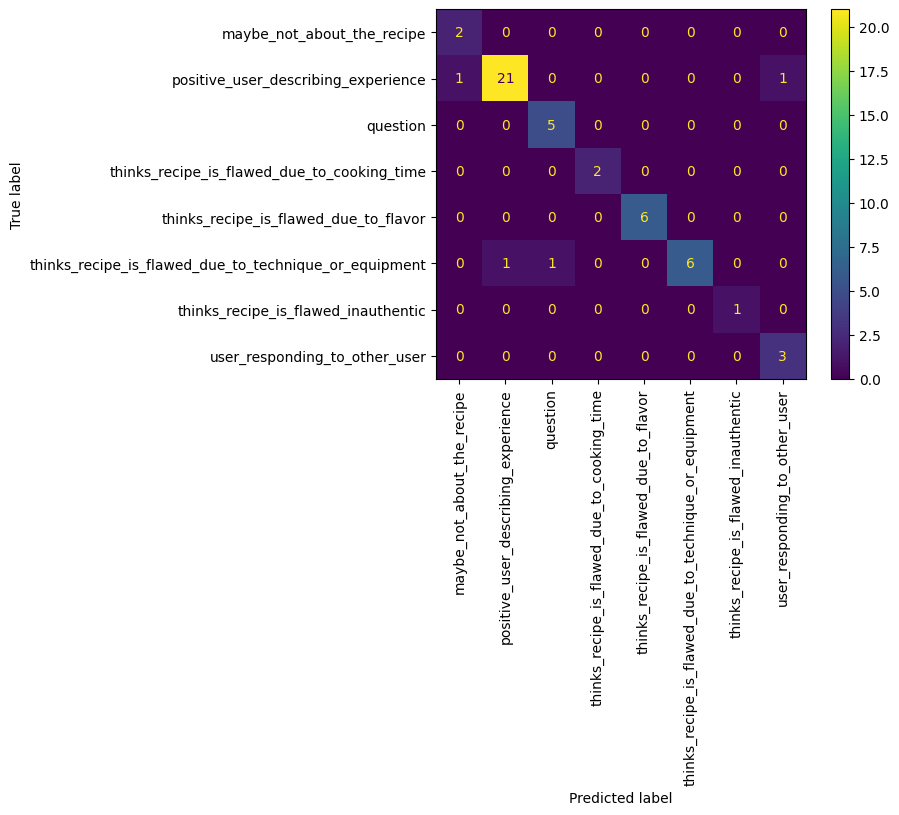

In [151]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(handcoded["groundtruth"], handcoded["ai_guess"],  xticks_rotation="vertical");
display(Markdown("""
  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  """))

In [120]:
# calculate baseline
accuracy = accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
most_common_answer = handcoded.groupby("groundtruth").count().idxmax().ai_guess
baseline = accuracy_score(handcoded["groundtruth"], [most_common_answer] * len(handcoded["ai_guess"]))


display(Markdown("""is {:.1%} good? Well, let's measure *model skill*. Is the AI _doing anything_?

Let's compare it to the stupidest model possible, that just guesses the most common class ({}) for all outputs. That **baseline** is {:.1%}.

How does {:.1%} compare to {:.1%}?
""".format(
    accuracy,
    most_common_answer,
    baseline,
    accuracy,
    baseline
)))

is 92.0% good? Well, let's measure *model skill*. Is the AI _doing anything_?

Let's compare it to the stupidest model possible, that just guesses the most common class (positive_user_describing_experience) for all outputs. That **baseline** is 46.0%.

How does 92.0% compare to 46.0%?


In [152]:
if accuracy <= baseline:
  new_baseline = accuracy_score(handcoded["groundtruth"], [most_common_answer] * len(handcoded["2-way_category_ai"]))

  display(Markdown("""
    The model is doing worse than (or maybe even with) the baseline.

    But that comparison treats false-positives and false-negatives as equally bad. That might not be right for your problem. For the insults problem,
    all we want to do is shrink the haystack. A baseline that guesses nothing is an insult (as our baseline does) is useless to us. The real
    baseline (reading all of Trump's tweets to find place insults) would be guessing the insult class for everything. That baseline gets {:.1%} --
    way worse than {}. Phew.

    This makes intuitive sense. An AI classification that shrinks the haystack, with a mixture of false-positives and true-positives for us to look at
    is actually really helpful.
  """.format(
      new_baseline,
      accuracy
  )))
else:
  display(Markdown("""
    The model is doing better than baseline.

But maybe we can do even better. Look at the model's mistakes below, adjust the prompt, and see if the accuracy score (or your chosen metric) goes up.
  """.strip()))

with pd.option_context("display.max_colwidth", 500):
  display(
      handcoded[handcoded["ai_guess"] != handcoded["groundtruth"]][[text_column_name, "groundtruth", "ai_guess"]]
  )

The model is doing better than baseline.

But maybe we can do even better. Look at the model's mistakes below, adjust the prompt, and see if the accuracy score (or your chosen metric) goes up.

,commentBody,groundtruth,ai_guess
url,,,
https://cooking.nytimes.com/recipes/1027498-vietnamese-coffee-swirl-brownies,Did anyone else find these very oily?,thinks_recipe_is_flawed_due_to_technique_or_equipment,question
https://cooking.nytimes.com/recipes/780934238-cold-peanut-ginger-noodles,"This looks delicious for hot summer days ahead.\nReading thru the comments, there are so many variations for this one recipe. I have never seen a pasta or egg noodle I didn't like. \nKudos to Melissa Clark.",positive_user_describing_experience,maybe_not_about_the_recipe
https://cooking.nytimes.com/recipes/1026376-halloumi-stuffed-sweet-peppers,Delicious! Used paneer mixed with garlic and oregano like JP suggested and fake crostinis I made from sandwich bread.,positive_user_describing_experience,user_responding_to_other_user
https://cooking.nytimes.com/recipes/1023880-vegetarian-tamale-pie,"Made it for the first time for the family tonight. Overall, it turned out tasty, the chili was flavorful and the cornbread was moist. The only downside was that the cornbread only covered about half the chili. If you have a large dutch oven, I’d highly recommend doubling the cornbread amounts - next time, that’s what I’ll do.",thinks_recipe_is_flawed_due_to_technique_or_equipment,positive_user_describing_experience


#### Suppose we only care about one topic.

Maybe your editor decides that we don't care about politics anymore. Just whether Elon's tweets are about his companies. Now, we just have a true-false classification problem.

In [122]:
CommentOptions.companies.value

NameError: name 'MuskTweetOptions' is not defined

In [154]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(handcoded["groundtruth"] == CommentOptions.companies.value, handcoded["ai_guess"] == MuskTweetOptions.companies.value,  xticks_rotation="vertical");
display(Markdown("""
  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  """))

AttributeError: type object 'CommentOptions' has no attribute 'companies'

The rate of false positives is how many non-company tweets we mistakenly said were about his companies.

The rate of false negatives is how many company tweets we missed.

The inverse of the false positive rate is the true positive rate, or **precision**.

The inverse of the false negative rate is the true negative rate. That's **recall**.


In [38]:

from sklearn.metrics import precision_score, recall_score
display(Markdown("Precision score: {:.1%}. Is that good?".format(
    precision_score(handcoded["groundtruth"] == MuskTweetOptions.companies.value, handcoded["ai_guess"] == MuskTweetOptions.companies.value)
)))


from sklearn.metrics import precision_score, recall_score
display(Markdown("Recall score: {:.1%}. Is that good?".format(
    recall_score(handcoded["groundtruth"] == MuskTweetOptions.companies.value, handcoded["ai_guess"] == MuskTweetOptions.companies.value)
)))


Precision score: 90.9%. Is that good?

Recall score: 52.6%. Is that good?

Which do we care about more? Precision or recall? (You tell me!)

These concepts (accuracy, model skill, precision and recall) might be what you'd put in your methodology to prove that your AI was reliable enough. Can you think of situations where you'd use one or another?

We're going to go back in Powerpoint to discuss:

- What kind of accuracy (or precision, or recall, or model skill) is good enough
- How to improve your prompts

## Try a new prompt

And we will see if it does better or worse.

To start out with, try one of these:

- cajoling the model to do a better job

- giving it some examples, based on the errors we saw above

In [57]:
new_prompt_base = """

Please read this tweet from Elon Musk and tell me which category best describes
it, choosing from just these options: {categories}. Return only the topic name,
nothing else.

FYI, Elons companies include:
spacex, which builds and launches rockets, space travel, mars. 
Tesla, which does electric vehicles.
Starlink which does satellites and internet
Grok which is an AI chatbot
X, which is used to be called twitter, among others. 

Also, a lot of times Elon chimes into political conversations that kindof coded, or cultural, but you might not recognize them if you're not in the know, so make sure to look out for that. ALSO, please be sure to read into the content of the tweet. Don't just rely on keywords. 

I will punch your grandma if you get it wrong.

Here is the tweet: {tweet_text}

"""

data_sample_new_prompt_column = handcoded.apply(lambda row: new_prompt_base.format(
    tweet_text=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in MuskTweetOptions])
), axis="columns")
token_count_sample = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(data_sample_new_prompt_column))
"Sample would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_sample))



'Sample would cost: $0.07'

In [58]:
handcoded["new_ai_guess"] = data_sample_new_prompt_column.progress_apply(classify)

100%|████████████████████████████████████████████████████| 50/50 [03:39<00:00,  4.40s/it]


In [155]:
accuracy = accuracy_score(handcoded["groundtruth"], handcoded["new_ai_guess"])
original_prompt_accuracy = accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])

KeyError: 'new_ai_guess'

In [60]:
display(Markdown("""
  Your new prompt got an accuracy rate of {:.0%}. Is that better than {:.0%}?

  Should we be using a different metric? (You tell me!)

  Keep trying new stuff until it's good enough (whatever that means!) or you get bored.

  Then you can classify the whole dataset.
""".format(accuracy, original_prompt_accuracy)))


  Your new prompt got an accuracy rate of 74%. Is that better than 54%?

  Should we be using a different metric? (You tell me!)

  Keep trying new stuff until it's good enough (whatever that means!) or you get bored.

  Then you can classify the whole dataset.


## Doing the whole thing

Once we're ready, and we think we've accounted for most of the mistakes, we're ready to classify the WHOLE THING.

In [ ]:
# since running the AI over the whole dataset might cost a real amount of money
# this is just an extra check to make sure you want to do it.
# just hit enter (or type anything) to continue
# hit stop (to the left of this cell) to stop
okay_to_do_the_whole_thing = input()

In [ ]:
## creating response generator -- full dataset

# we're using the most recent "new prompt"

data_full_prompt_column = new_prompt_base + data_full[text_column_name]

In [ ]:
## classifying full prompt

data_full["ai_guess"] = data_full_prompt_column.progress_apply(classify)
data_full.to_csv(data_dir + 'elon_tweets_ai_classified.csv')